### Multiple Schemas
There are cases where we may want a bit more control over this
- Internal nodes may pass information that is not required in the graph's input/output
- We may also want to use different input/output schemas for the graph. The output might, for example, only contain output key

##### Simple State

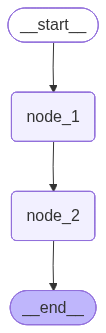

In [2]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph

class OverallState(TypedDict):
    foo: int
    baz: int

def node_1(state: OverallState) -> OverallState:
    print("---Node 1---")
    return {"baz": state['foo'] + 1}

def node_2(state: OverallState) -> OverallState:
    print("---Node 2---")
    return {"foo": state['baz'] + 1}

# Build Graph
builder: StateGraph = StateGraph(OverallState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Logic
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# Add
graph: CompiledStateGraph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [3]:
graph.invoke({"foo": 1})

---Node 1---
---Node 2---


{'foo': 3, 'baz': 2}

##### Private State
This is useful for anything needed as part of the intermediate working logic of the graph, but not relevant for the overall graph input or output
- We'll define an OverallState and a PrivateState
    - node_2 uses PrivateState as input, but writes out to OverallState

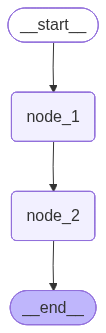

In [4]:
from typing_extensions import TypedDict
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph

class OverallState(TypedDict):
    foo: int

class PrivateState(TypedDict):
    baz: int

def node_1(state: OverallState) -> PrivateState:
    print("---Node 1---")
    return {"baz": state['foo'] + 1}

def node_2(state: PrivateState) -> OverallState:
    print("---Node 2---")
    return {"foo": state['baz'] + 1}

# Build Graph
builder: StateGraph = StateGraph(OverallState)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)

# Logic 
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

# Add
graph: CompiledStateGraph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
graph.invoke({"foo": 1})

---Node 1---
---Node 2---


{'foo': 3}

*baz is only included in PrivateState*

*node_2 uses PrivateState as input, but writes out to OverallState*

- So we can see that baz is excluded from the graph output because it is not in OverallState

##### Input/Output Schema
By default, Stategraph takes in a single schema and all nodes are expected to communicate with that schema
- However it is also possible to define explicit input and output schema for a graph.
- Often, in these cases, we define an "internal" schema that contains all keys relevant to graph operations
- But we use specific input and output schemas to constrain the input and output


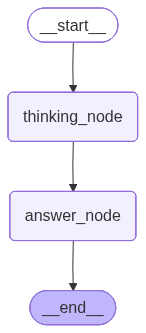

In [16]:
class OverallState(TypedDict):
    question: str
    answer: str
    notes: str  

def thinking_node(state: OverallState) -> OverallState:
    return {"answer": "bye", "notes": "... His name is Moiz"}

def answer_node(state: OverallState) -> OverallState:
    return {"answer": "Bye Moiz"}

graph: StateGraph = StateGraph(OverallState)
graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)

graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph: CompiledStateGraph = graph.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [17]:
graph.invoke({"question": "hi", "answer": "", "notes": ""})

{'question': 'hi', 'answer': 'Bye Moiz', 'notes': '... His name is Moiz'}

*let's use a specific input and output schema with our graph*
- Here input and output schemas perform filtering on what keys are permitted on the input and output of the graph
- In addition, we can use a type hint  state: InputState to specify the input schema of each of our nodes.

C:\Users\moiza\AppData\Local\Temp\ipykernel_2560\420007712.py:18: LangGraphDeprecatedSinceV05: `input` is deprecated and will be removed. Please use `input_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  graph: StateGraph = StateGraph(OverallState, input=InputState, output=OutputState)
C:\Users\moiza\AppData\Local\Temp\ipykernel_2560\420007712.py:18: LangGraphDeprecatedSinceV05: `output` is deprecated and will be removed. Please use `output_schema` instead. Deprecated in LangGraph V0.5 to be removed in V2.0.
  graph: StateGraph = StateGraph(OverallState, input=InputState, output=OutputState)


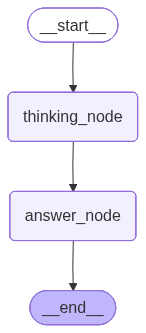

In [19]:
class InputState(TypedDict):
    question: str

class OutputState(TypedDict):
    answer: str

class OverallState(TypedDict):
    question: str
    answer: str
    notes: str

def thinking_node(state: InputState):
    return {"ansswer": "bye", "notes": "... his name is Moiz"}

def answer_node(state: OverallState):
    return {"answer": "Bye Moiz"}

graph: StateGraph = StateGraph(OverallState, input=InputState, output=OutputState)

graph.add_node("answer_node", answer_node)
graph.add_node("thinking_node", thinking_node)

graph.add_edge(START, "thinking_node")
graph.add_edge("thinking_node", "answer_node")
graph.add_edge("answer_node", END)

graph: CompiledStateGraph = graph.compile()

display(Image(graph.get_graph(). draw_mermaid_png()))

In [20]:
graph.invoke({"question": "hi"})

{'answer': 'Bye Moiz'}

### Trim Filter Messages

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")


In [3]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(f"So you said you were researching ocean mammals", name="Bot")]
messages.append(HumanMessage(f"Yes, I know about whales. But what others should I learn about? Give one line answer.", name="Moiz"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals
================================ Human Message =================================
Name: Moiz

Yes, I know about whales. But what others should I learn about? Give one line answer.


In [4]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
llm.invoke(messages)

AIMessage(content='You could learn about seals, sea lions, walruses, manatees, dugongs, sea otters, and polar bears.', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019efaf9-ba35-7d20-8a64-b7bf248c6a1f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 30, 'output_tokens': 449, 'total_tokens': 479, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 421}})

*We can run our chat model in a simple graph with MessageState*

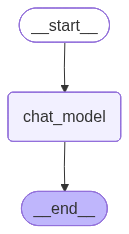

In [5]:
from IPython.display import Image, display
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langgraph.graph.state import CompiledStateGraph

# Node
def chat_model_node(state: MessagesState) -> MessagesState:
    return {"messages": llm.invoke(state["messages"])}

# Build Graph
builder: StateGraph = StateGraph(MessagesState)

builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "chat_model")
builder.add_edge("chat_model", END)

graph: CompiledStateGraph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
output = graph.invoke({'messages': messages})
for m in output['messages']:
    m.pretty_print()

================================== Ai Message ==================================
Name: Bot

So you said you were researching ocean mammals
================================ Human Message =================================
Name: Moiz

Yes, I know about whales. But what others should I learn about? Give one line answer.
================================== Ai Message ==================================

Beyond whales, explore dolphins, seals, sea lions, manatees, dugongs, and sea otters.


In [9]:
async for m in graph.astream_events({'messages': messages}, version="v2"):
    print(m)
    # on_chain_start = start of a node's execution
    # on_chain_end = indicates the completion of node's execution
    # on_chain_stream = represent intermediate data or progress updates during a node's execution

    print("\n-----------------\n")

{'event': 'on_chain_start', 'data': {'input': {'messages': [AIMessage(content='So you said you were researching ocean mammals', additional_kwargs={}, response_metadata={}, name='Bot', id='1150192d-dc6b-4abb-924d-622f73060c47', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Yes, I know about whales. But what others should I learn about? Give one line answer.', additional_kwargs={}, response_metadata={}, name='Moiz', id='9c851551-df8e-419c-a752-08beb3360a88')]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019efb01-95cf-7260-ab4a-f816453d761d', 'metadata': {'ls_integration': 'langgraph'}, 'parent_ids': []}

-----------------

{'event': 'on_chain_start', 'data': {'input': {'messages': [AIMessage(content='So you said you were researching ocean mammals', additional_kwargs={}, response_metadata={}, name='Bot', id='1150192d-dc6b-4abb-924d-622f73060c47', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content='Yes, I know about whales. But what others should I learn about? Gi

##### Reducer
A practical challenege when working with messages is managing long-running conversations.
- Long running conversations result in high token usage and latency if we are not careful b/c we pass a growing list of messages to the model

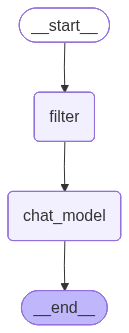

In [11]:
from langchain_core.messages import RemoveMessage

# Nodes
def filter_messages(state: MessagesState) -> MessagesState:
    # Delete all but the 2 most recent messages
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    print(delete_messages)
    return {"messages": delete_messages}

def chat_model_node(state: MessagesState) -> MessagesState:
    return {"messages": [llm.invoke(state["messages"])]}

# Build Graph
builder: StateGraph = StateGraph(MessagesState)

builder.add_node("filter", filter_messages)
builder.add_node("chat_model", chat_model_node)

builder.add_edge(START, "filter")
builder.add_edge("filter", "chat_model")
builder.add_edge("chat_model", END)

graph: CompiledStateGraph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
# # Message list with a preamble
# messages = [AIMessage("Hi. ", name="Bot", ide="1")]
# messages.append(HumanMessage("Hi.", name="Moiz", id="2"))
# messages.append(AIMessage("So you were research about ocean mamals?", name="Bot", id="3"))
# messages.append(HumanMessage("Yes, I know whales, what about other should I learn?", name="Moiz", id="4"))

# # Invoke
# output = graph.invoke({'messages': messages})
# for m in output['messages']:
#     m.pretty_print()